#  Customer Churn Analysis

## Overview

Customer churn refers to customers leaving a company's services. Understanding churn patterns helps businesses identify factors that influence customer retention.

In this project, I perform exploratory data analysis (EDA) on a telecom customer dataset to understand customer characteristics and identify patterns associated with customer churn.

## Problem Statement

Customer churn is a major challenge for subscription-based businesses because losing customers directly impacts revenue and growth.

The goal of this analysis is to explore customer data and identify patterns associated with churn using exploratory data analysis techniques.

## Objectives

- Explore customer demographics and service usage patterns
- Analyze factors associated with customer churn
- Identify trends through exploratory data analysis
- Generate insights from visualizations and customer data

## Dataset Summary

Domain: Telecommunications
- Records: 7,043 customers
- Features: 21 columns
- Domain: Telecommunications
- Target Variable: Churn

## Tools Used

- Python
- Pandas
- NumPy
- Matplotlib
- Seaborn


## Importing Required Libraries

The following libraries are used for data manipulation, numerical operations and visualization.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Loading the Dataset

Reading the telecom customer dataset into a pandas DataFrame for analysis.

In [3]:
df =pd.read_csv("Customer Churn.csv")
df

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,6840-RESVB,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,...,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.5,No
7039,2234-XADUH,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.9,No
7040,4801-JZAZL,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7041,8361-LTMKD,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.6,Yes


## Dataset Information

The dataset contains customer demographic information, subscribed services, billing details, contract information and churn status.

Key columns include:

- Gender
- SeniorCitizen
- Partner
- Tenure
- Contract
- MonthlyCharges
- TotalCharges
- Churn

## Initial Data Exploration

Understanding the size, structure and data types present in the dataset.

In [6]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

In [8]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
count,7043.000000,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692,2279.734304
std,0.368612,24.559481,30.090047,2266.794470
min,0.000000,0.000000,18.250000,0.000000
25%,0.000000,9.000000,35.500000,398.550000
50%,0.000000,29.000000,70.350000,1394.550000
75%,0.000000,55.000000,89.850000,3786.600000
max,1.000000,72.000000,118.750000,8684.800000


## Data Cleaning

Missing values in the TotalCharges column were represented as blank strings. These values were replaced and converted to numeric format for analysis.

In [4]:
df["TotalCharges"] =df["TotalCharges"].replace(" ","0")
df["TotalCharges"] =df["TotalCharges"].astype("float")


In [9]:
df.isnull().sum().sum()

np.int64(0)

In [10]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
count,7043.000000,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692,2279.734304
std,0.368612,24.559481,30.090047,2266.794470
min,0.000000,0.000000,18.250000,0.000000
25%,0.000000,9.000000,35.500000,398.550000
50%,0.000000,29.000000,70.350000,1394.550000
75%,0.000000,55.000000,89.850000,3786.600000
max,1.000000,72.000000,118.750000,8684.800000


In [11]:
df["customerID"].duplicated().sum()

np.int64(0)

## Data Transformation

The SeniorCitizen column was converted from binary values (0 and 1) to more readable categories (No and Yes).

In [12]:
def conv(value):
    if value == 1:
        return "yes" 
    else:
        return "no"
    
df["SeniorCitizen"] = df["SeniorCitizen"].apply(conv)
df.head(25)
        

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,no,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,no,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,3668-QPYBK,Male,no,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,no,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,no,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
5,9305-CDSKC,Female,no,No,No,8,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,99.65,820.50,Yes
6,1452-KIOVK,Male,no,No,Yes,22,Yes,Yes,Fiber optic,No,...,No,No,Yes,No,Month-to-month,Yes,Credit card (automatic),89.10,1949.40,No
7,6713-OKOMC,Female,no,No,No,10,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,No,Mailed check,29.75,301.90,No
8,7892-POOKP,Female,no,Yes,No,28,Yes,Yes,Fiber optic,No,...,Yes,Yes,Yes,Yes,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes
9,6388-TABGU,Male,no,No,Yes,62,Yes,No,DSL,Yes,...,No,No,No,No,One year,No,Bank transfer (automatic),56.15,3487.95,No


## Exploratory Data Analysis (EDA)

In this section, customer demographics, service usage patterns, contract details, and billing information are analyzed to identify factors associated with customer churn.

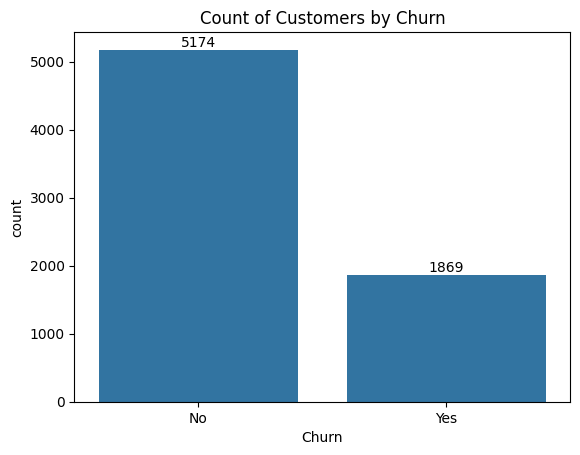

In [13]:
ax = sns.countplot(x = "Churn", data = df)
ax.bar_label(ax.containers[0])
plt.title("Count of Customers by Churn")
plt.show()

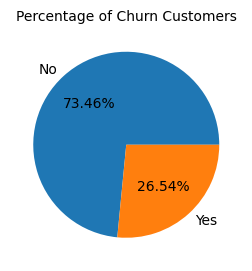

In [14]:
plt.figure(figsize=(3,4))
gb = df.groupby("Churn").agg({"Churn":"count"})
plt.pie(gb["Churn"], labels= gb.index, autopct = "%1.2f%%")
plt.title("Percentage of Churn Customers",fontsize=10)
plt.show()

### Observation

Approximately 26.5% of customers have churned while the majority remain with the company. Further analysis is performed to identify factors associated with customer churn.

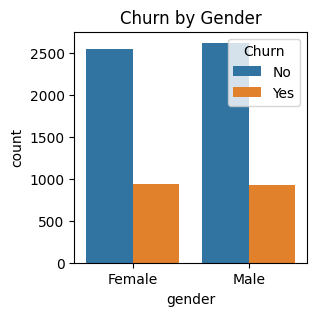

In [15]:
plt.figure(figsize=(3,3))
sns.countplot(x= "gender", data = df, hue = "Churn")
plt.title("Churn by Gender")
plt.show()

### Observation

Churn patterns appear relatively similar across male and female customers, suggesting gender may not be a major factor influencing churn.

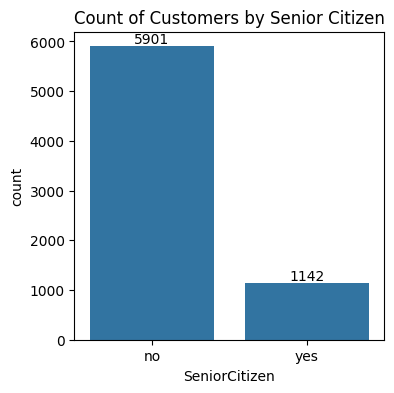

In [16]:
plt.figure(figsize=(4,4))
ax= sns.countplot(x= "SeniorCitizen", data = df)
ax.bar_label(ax.containers[0])
plt.title("Count of Customers by Senior Citizen")
plt.show()


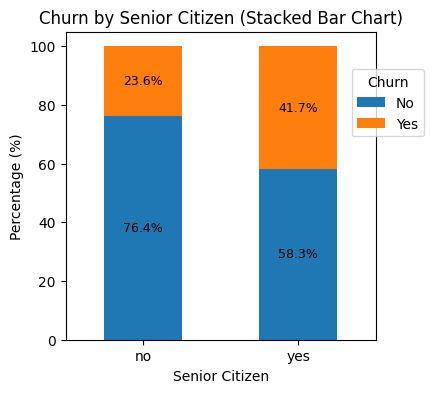

In [17]:
import matplotlib.pyplot as plt

# Calculate percentage churn by SeniorCitizen
total_counts = (
    df.groupby("SeniorCitizen")["Churn"]
      .value_counts(normalize=True)
      .unstack() * 100
)

# Create plot
fig, ax = plt.subplots(figsize=(4,4))

# Plot stacked bar chart
total_counts.plot(
    kind="bar",
    stacked=True,
    ax=ax,
    color=["#1f77b4", "#ff7f0e"]
)

# Add percentage labels
for p in ax.patches:
    width = p.get_width()
    height = p.get_height()

    if height > 0:
        x, y = p.get_xy()
        ax.text(
            x + width / 2,
            y + height / 2,
            f"{height:.1f}%",
            ha="center",
            va="center",
            fontsize=9
        )

# Formatting
plt.title("Churn by Senior Citizen (Stacked Bar Chart)")
plt.xlabel("Senior Citizen")
plt.ylabel("Percentage (%)")
plt.xticks(rotation=0)

plt.legend(title="Churn", bbox_to_anchor =(0.9,0.9))

plt.show()

### Observation

Senior citizens exhibit a higher proportion of churn compared to non-senior customers, indicating that this customer segment may be more likely to discontinue services.

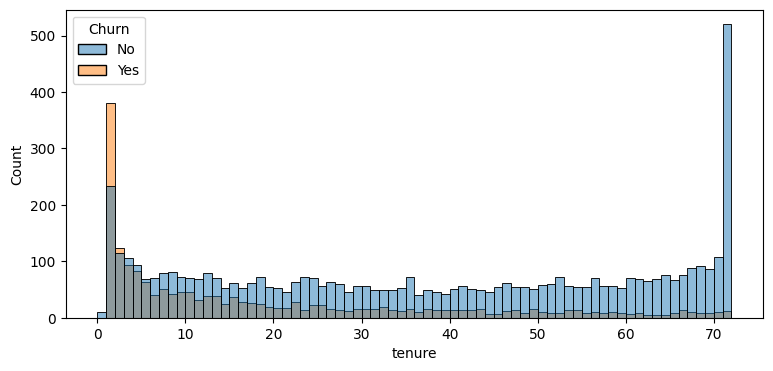

In [18]:
plt.figure(figsize=(9,4))
sns.histplot(x= 'tenure', data =df, bins=72 , hue='Churn')
plt.show()

### Observation

Customers with longer tenure generally show lower churn rates, suggesting that long-term customers are more likely to remain with the company.

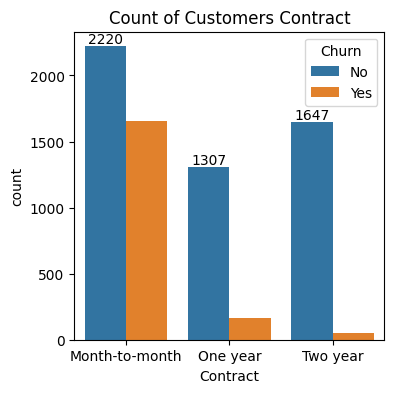

In [19]:
plt.figure(figsize=(4,4))
ax= sns.countplot(x= "Contract", data = df, hue='Churn')
ax.bar_label(ax.containers[0])
plt.title("Count of Customers Contract")
plt.show()


### Observation

Customers with month-to-month contracts exhibit noticeably higher churn compared to customers on longer-term contracts.

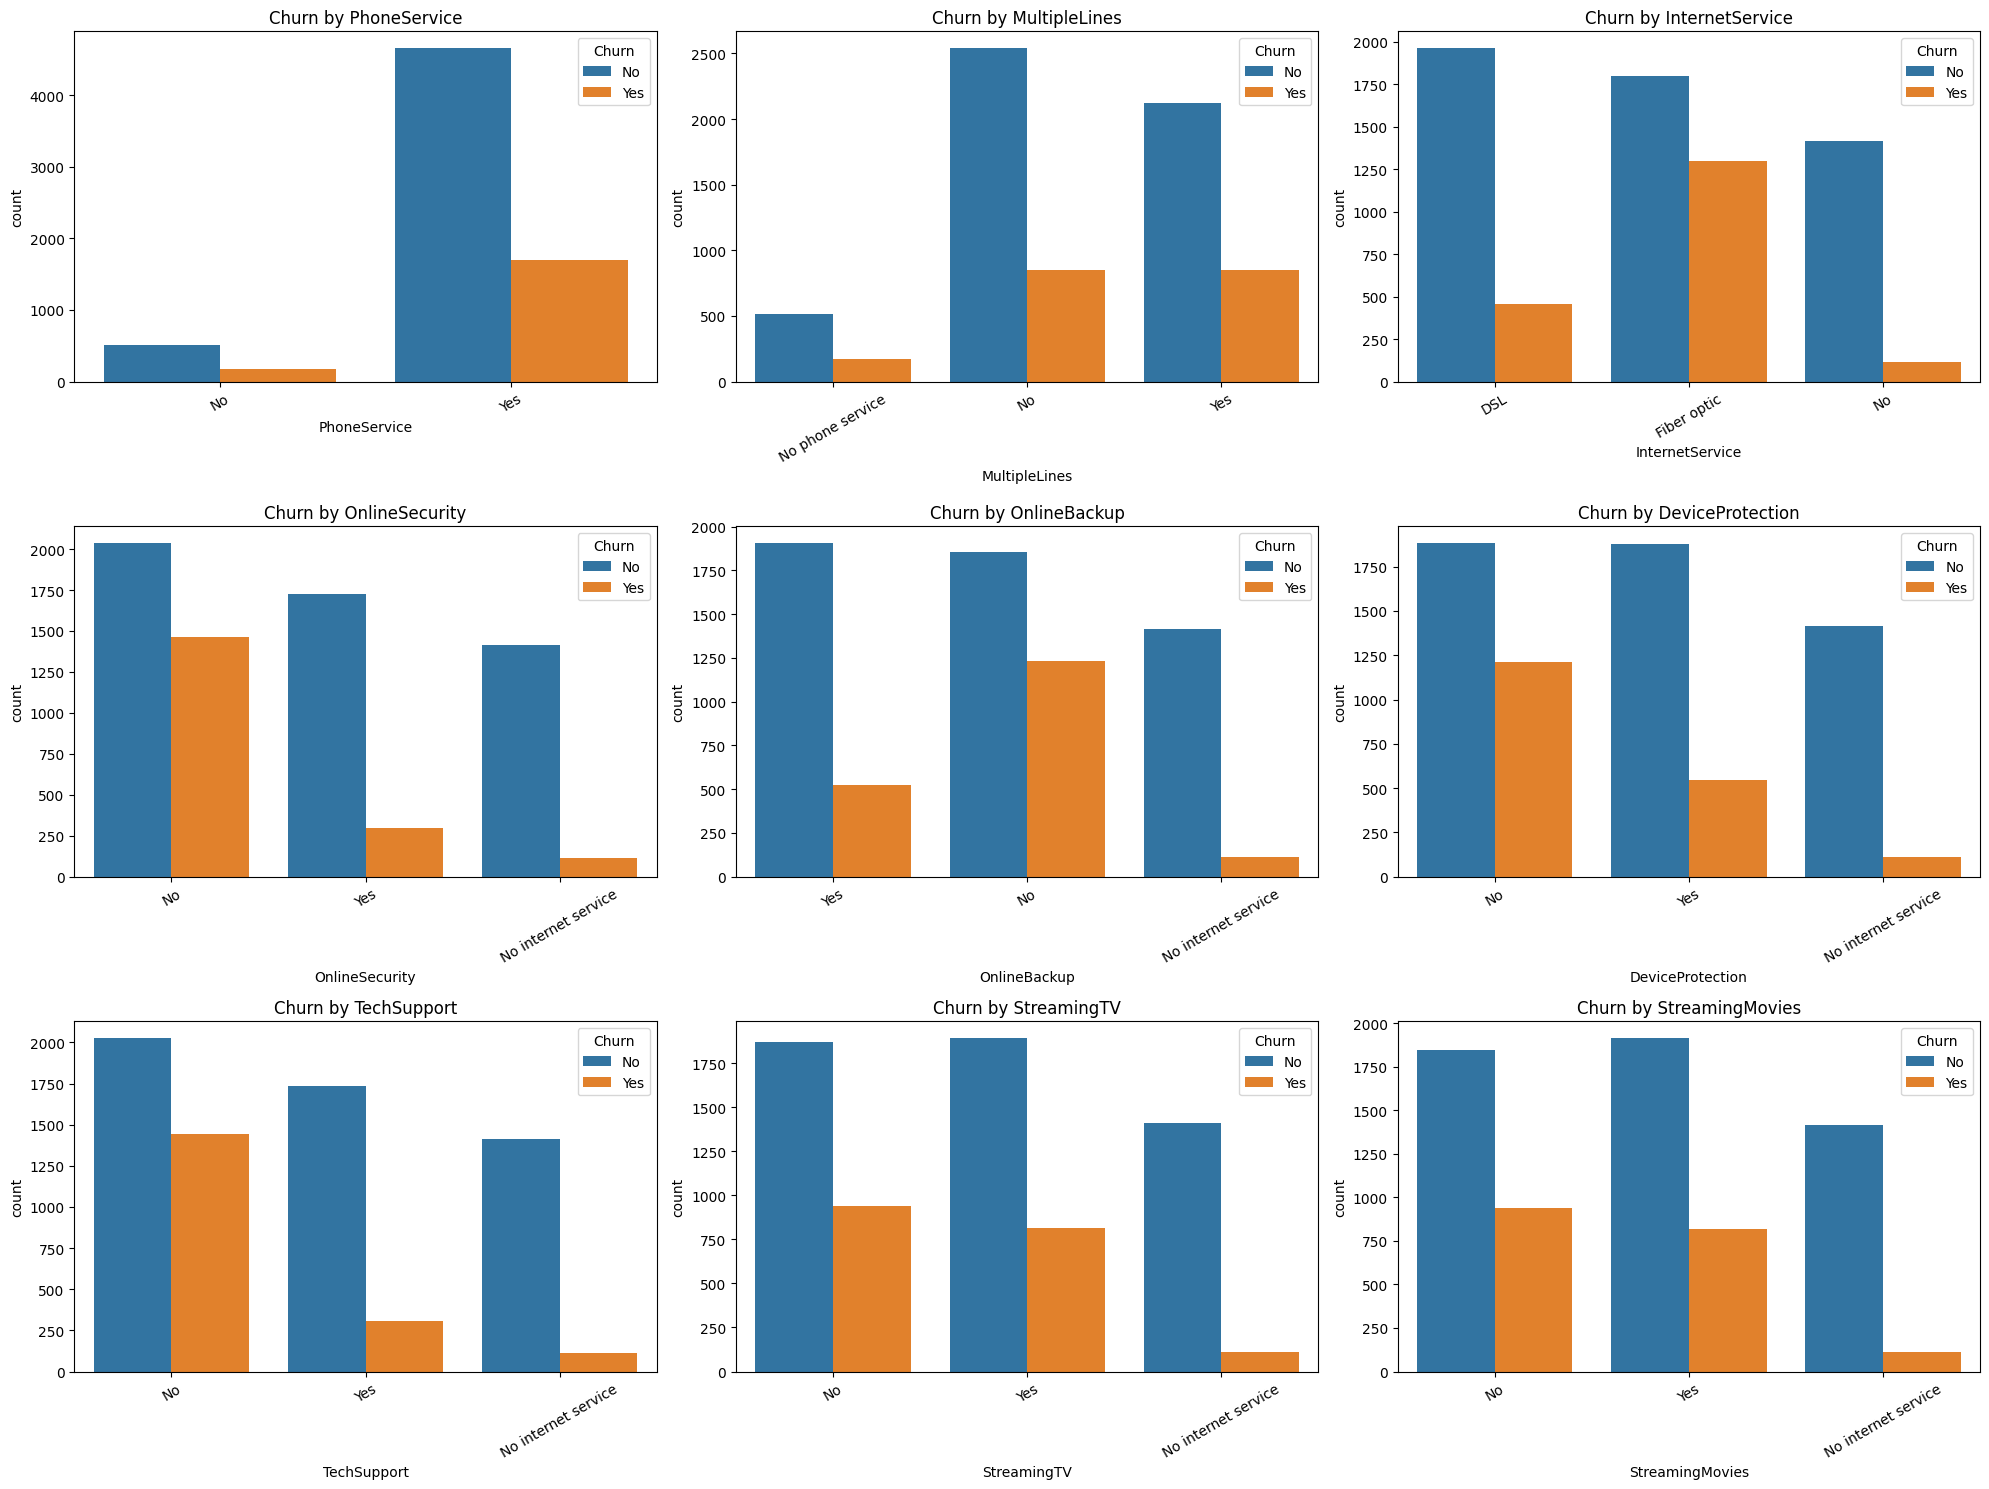

In [20]:
cols = [
    'PhoneService',
    'MultipleLines',
    'InternetService',
    'OnlineSecurity',
    'OnlineBackup',
    'DeviceProtection',
    'TechSupport',
    'StreamingTV',
    'StreamingMovies'
]

fig, axes = plt.subplots(3, 3, figsize=(20, 15))

axes = axes.flatten()

for i, col in enumerate(cols):

    sns.countplot(
        data=df,
        x=col,
        hue='Churn',
        ax=axes[i]
    )

    axes[i].set_title(f'Churn by {col}')
    axes[i].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()



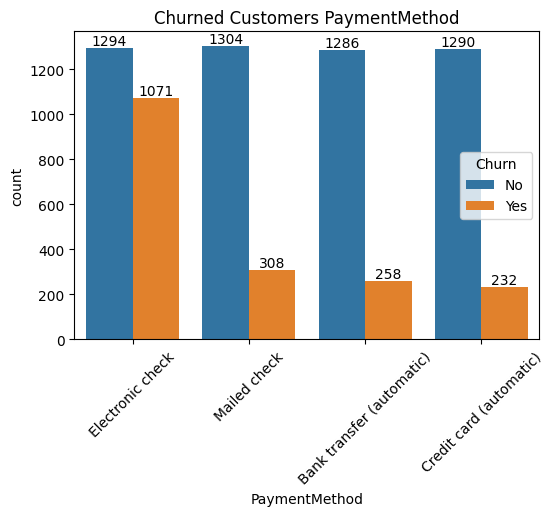

In [21]:
plt.figure(figsize=(6,4))
ax= sns.countplot(x= "PaymentMethod", data = df, hue='Churn')
ax.bar_label(ax.containers[0])
ax.bar_label(ax.containers[1])
plt.title("Churned Customers PaymentMethod")
plt.xticks(rotation = 45)
plt.show()


# Key Insights

1. Customers on month-to-month contracts have the highest churn rates.

2. Customers with shorter tenure are more likely to discontinue services.

3. Senior citizens show relatively higher churn behavior.

4. Electronic check users exhibit higher churn compared to other payment methods.

5. Long-term contracts contribute to better customer retention.

# Conclusion

From the analysis, the following patterns were observed:

1. Customers with month-to-month contracts tend to churn more frequently.

2. New customers with lower tenure show higher churn rates compared to long-term customers.

3. Electronic check users appear to have higher churn levels.

4. Senior citizens show slightly higher churn behavior than non-senior customers.

5. Long-term contract customers are generally more likely to stay with the company.

This project helped in understanding the complete EDA workflow including data cleaning, visualization and insight generation using Python.

# What I Learned

Through this project I gained hands-on experience in:

- Data cleaning using Pandas
- Exploratory data analysis (EDA)
- Data visualization using Matplotlib and Seaborn
- Extracting insights from customer behavior data
- Presenting findings through structured analysis